# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Штурин Захарій Михайлович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 6     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 6 · Штурин Захарій Михайлович, ШІ-34, «Longer Boats»
Підприємство «Longer Boats» виготовляє яхти. Одиниця виміру плану: шт./місяць.

                       Sting  Ray  Breaker  Marlin  ЗАПАС
Склопластик, м²            3    2        1       4    630
Столярний цех, год         4    2        2       1    391
Фарбувальний цех, год      3    5        1       2   1349
Такелаж, компл.            3    2        0       2    811
Ділянка добудови, год      6    4        6       3   1085

                    Sting  Ray  Breaker  Marlin
Прибуток з одиниці     40   62       19      57

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Столярний цех, год
  ціна:   29.5 за одиницю
  обсяг:  до 268 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1 - яхти Sting, x2 - яхти Ray, x3 - яхти Breaker, x4 - яхти Marlin

Цільова функція: 

$$
\begin{aligned}
max Z = 40x1 + 62x2 + 19x3 + 57x4
\end{aligned}
$$

Обмеження: 


$$
\begin{aligned}
3x_1 + 2x_2 + x_3 + 4x_4 &\leq 630 && \text{(склопластик)}\\
4x_1 + 2x_2 + 2x_3 + x_4 &\leq 391 && \text{(столярний цех)}\\
3x_1 + 5x_2 + x_3 + 2x_4 &\leq 1349 && \text{(фарбувальний цех)}\\
3x_1 + 2x_2 + 2x_4 &\leq 811 && \text{(такелаж)}\\
6x_1 + 4x_2 + 6x_3 + 3x_4 &\leq 1085 && \text{(ділянка добудови)}
\end{aligned}
$$

Невід'ємність:

$$
\begin{aligned}
x1,x2,x3,x4 &\geq 0
\end{aligned}
$$

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** бо його значення вже задане умовою задачі, якби ми могли докупити цей ресурс, то він вже би став змінною рішення, бо у моделі появиться нова змінна, яка б віднімала гроші, аби докупити ресурс

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 155.667, 0, 79.667]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 14192.333             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 155.667, 0, 79.667] | прибуток 14192.333


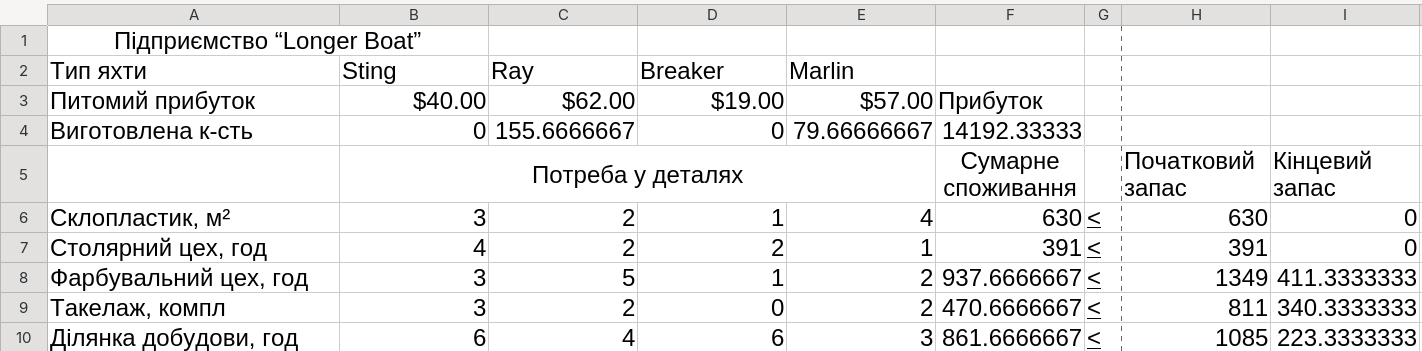

Побудова таблиці за даними значеннями

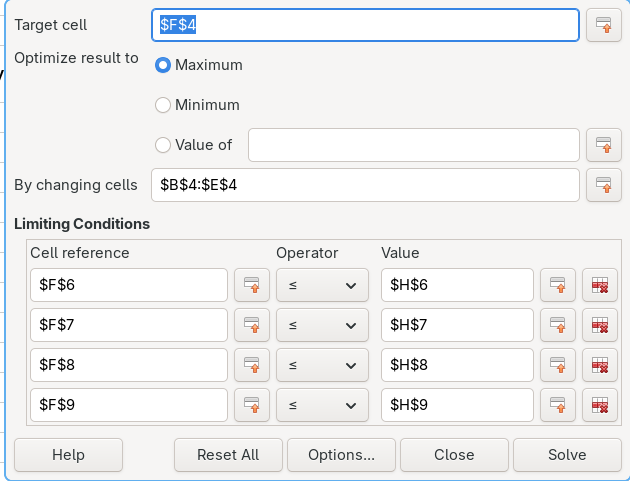

Введення параметрів для функції solve

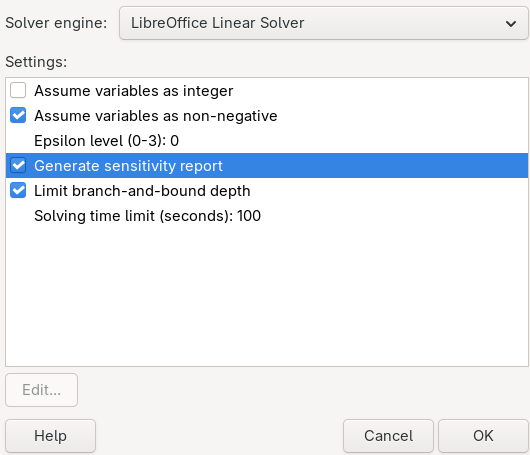

Додаткові опції моделі: невід'ємні числа, створити звіт чутливості та задали максимальний час очікування

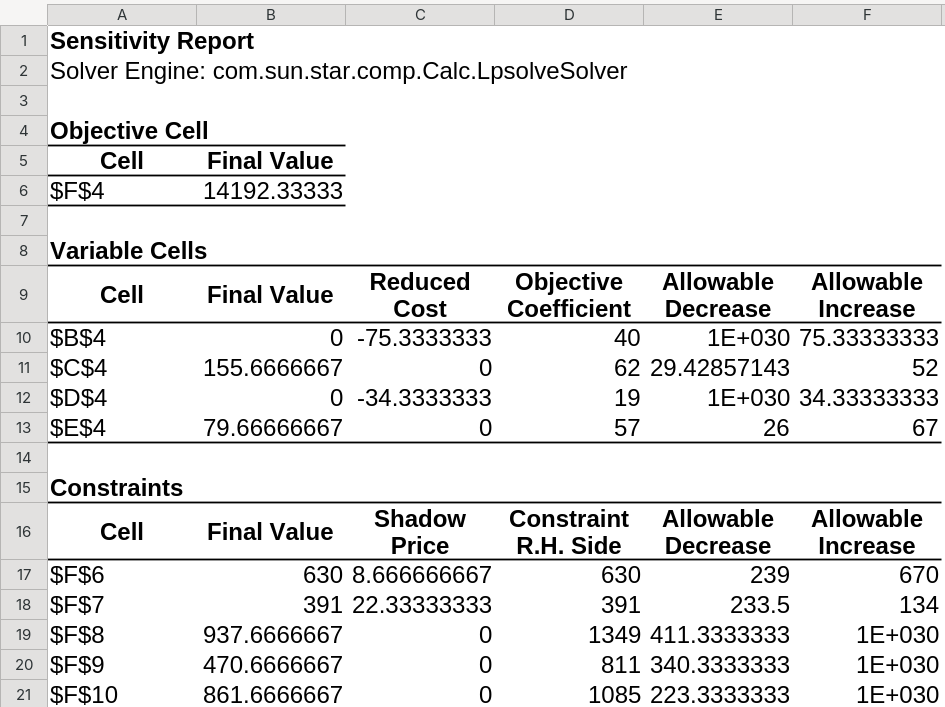

Звіт чутливості для задачі

---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
# ВАШ КОД
import numpy as np
c = np.array([40, 62, 19, 57])

A = np.array([
    [3, 2, 1, 4],
    [4, 2, 2, 1],
    [3, 5, 1, 2],
    [3, 2, 0, 2],
    [6, 4, 6, 3]
])

b = np.array([
    630,
    391,
    1349,
    811,
    1085
])

result = linprog(
    -c,
    A_ub=A,
    b_ub=b,
    bounds=(0, None),
    method="highs"
)

план = result.x
прибуток = -result.fun

print("План:", план)

print("Максимальний прибуток:", прибуток)

План: [  0.         155.66666667   0.          79.66666667]
Максимальний прибуток: 14192.333333333332


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Склопластик, м² | 630 | 8.667 | 630 | 670 | 239 |
| Столярний цех, год | 391 | 22.333 | 391 | 134 | 233.5 |
| Фарбувальний цех, год | 937.667 | 0 | 1349 | 1E+030 | 411.333 |
| Такелаж, компл | 470.667 | 0 | 811 | 1E+030 | 340.333 |
| Ділянка добудови, год | 861.667 | 0 | 1085 | 1E+030 | 223.333 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Sting | 0 | -75.333 | 40 | 75.333 | 1E+030 |
| Ray | 155.667 | 0 | 62 | 52 | 29.429 |
| Breaker | 0 | -34.333 | 19 | 34.333 | 1E+030 |
| Marlin | 79.667 | 0 | 57 | 67 | 26 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Це у двох виробах відбувається, у Sting та Breaker, оскільки у них від'ємна зведена вартість. щоб вони появились у оптимальному плані, їхня ціна має зрости на модуль від'ємної зведеної вартості


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
# ВАШ КОД
c = np.array([40, 62, 19, 57])

A = np.array([
    [3, 2, 1, 4],
    [4, 2, 2, 1],
    [3, 5, 1, 2],
    [3, 2, 0, 2],
    [6, 4, 6, 3]
])

b = np.array([
    630,
    392, #отут додав 1
    1349,
    811,
    1085
])

result = linprog(
    -c,
    A_ub=A,
    b_ub=b,
    bounds=(0, None),
    method="highs"
)

план_новий = result.x
прибуток_новий = -result.fun

print("План:", план)
print("План новий:", план_новий)

print("Максимальний прибуток:", прибуток)
print("Максимальний прибуток новий:", прибуток_новий)

print("Різниця:", прибуток_новий - прибуток)

План: [  0.         155.66666667   0.          79.66666667]
План новий: [  0.         156.33333333   0.          79.33333333]
Максимальний прибуток: 14192.333333333332
Максимальний прибуток новий: 14214.666666666668
Різниця: 22.33333333333576


**Відповідь 5.1:** приріст прибутку = 22.333, тіньова ціна така сама, отже збігаються

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

In [8]:
# ВАШ КОД
c = np.array([40, 62, 19, 57])

A = np.array([
    [3, 2, 1, 4],
    [4, 2, 2, 1],
    [3, 5, 1, 2],
    [3, 2, 0, 2],
    [6, 4, 6, 3]
])

b = np.array([630, 391, 1349, 811, 1085])
carpentry_stock = range(391, 527)

прибуток_новий = []

for stock in carpentry_stock:
    b_new = b.copy()
    b_new[1] = stock

    result = linprog(
        -c,
        A_ub=A,
        b_ub=b_new,
        bounds=(0, None),
        method="highs"
    )

    прибуток_новий.append(-result.fun)

збільшення_прибутку = np.diff(прибуток_новий)

increase_stock = list(carpentry_stock)[1:]

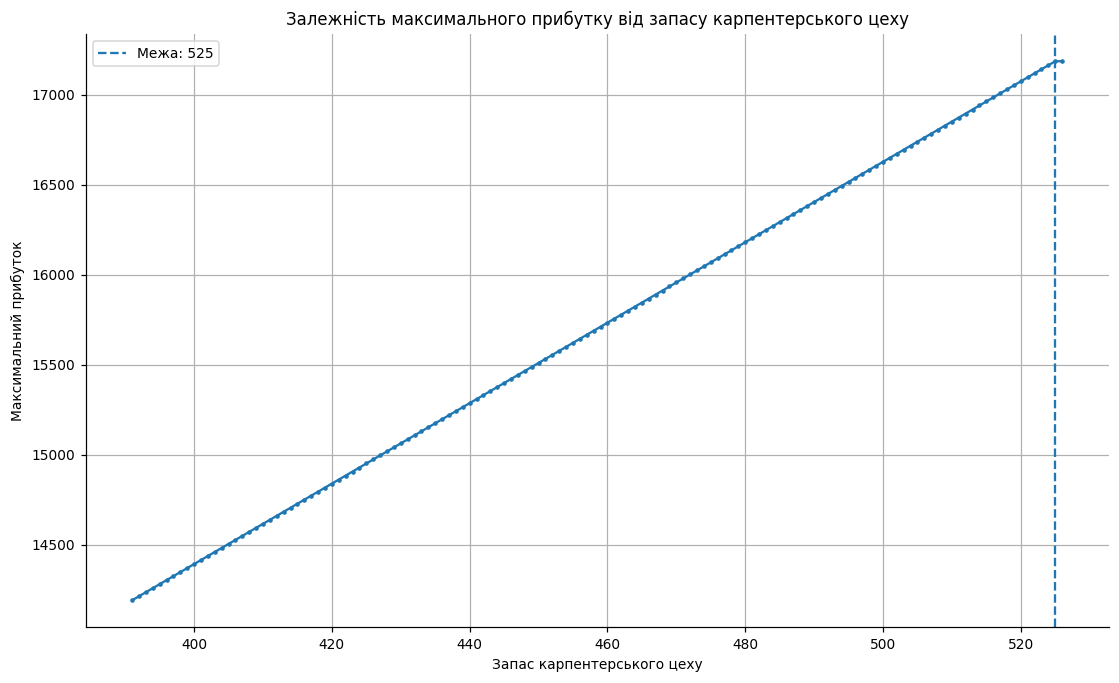

In [9]:
plt.figure(figsize=(12, 7))
plt.plot(carpentry_stock, прибуток_новий, marker="o", markersize=2)
plt.axvline(525, linestyle="--", label="Межа: 525")
plt.xlabel("Запас карпентерського цеху")
plt.ylabel("Максимальний прибуток")
plt.title("Залежність максимального прибутку від запасу карпентерського цеху")
plt.grid(True)
plt.legend()
plt.show()

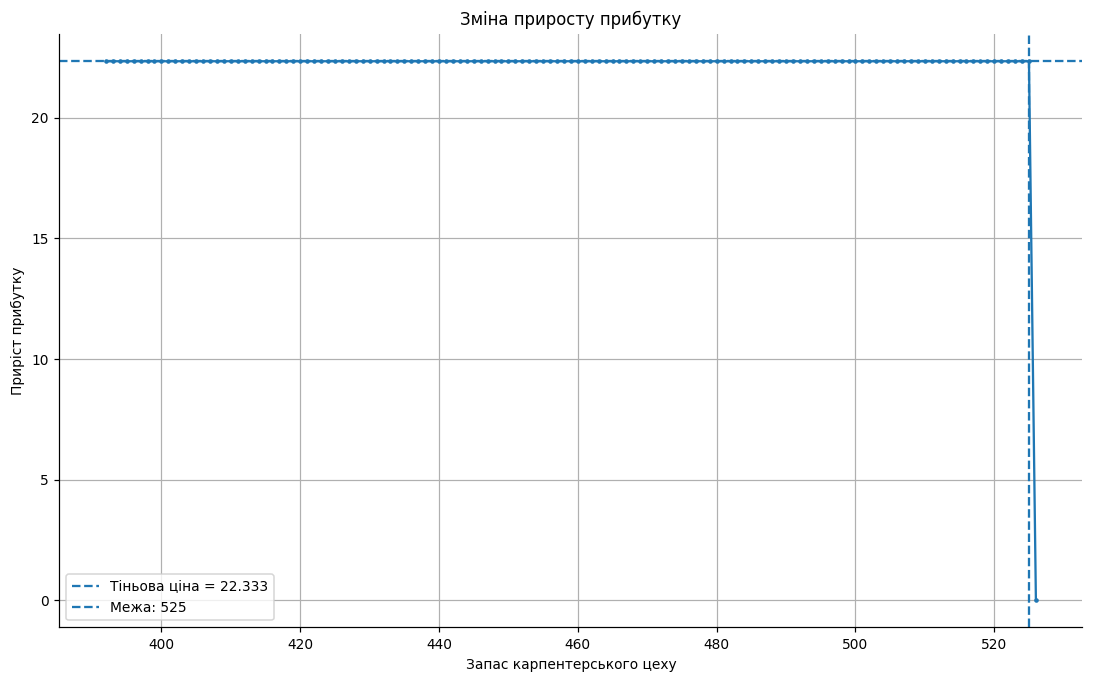

In [10]:
plt.figure(figsize=(12, 7))
plt.plot(increase_stock, збільшення_прибутку, marker="o", markersize=2)
plt.axhline(22.333333, linestyle="--", label="Тіньова ціна = 22.333")
plt.axvline(525, linestyle="--", label="Межа: 525")
plt.xlabel("Запас карпентерського цеху")
plt.ylabel("Приріст прибутку")
plt.title("Зміна приросту прибутку")
plt.grid(True)
plt.legend()
plt.show()

**Відповідь 5.2:** зараз базовий запас це 391, а за таблицею чутливості ми можемо побачити, що можна збільшити ще на 134, отже для максимальної вигоди треба збільшити запаси до 525 включно 

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [11]:
# ВАШ КОД
c = np.array([40, 62, 19, 57])

A = np.array([
    [3, 2, 1, 4],
    [4, 2, 2, 1],
    [3, 5, 1, 2],
    [3, 2, 0, 2],
    [6, 4, 6, 3]
])

b = np.array([
    630,
    391,
    1349,
    811,
    1085
])

result = linprog(
    -c,
    A_ub=A,
    b_ub=b,
    bounds=(0, None),
    method="highs"
)

прибуток_старий = -result.fun

print("Початковий план:", result.x)
print("Початковий прибуток:", прибуток_старий)

Початковий план: [  0.         155.66666667   0.          79.66666667]
Початковий прибуток: 14192.333333333332


In [12]:
ціна = 29.5
обсяг = 268

b_new = b.copy()
b_new[1] += обсяг

result_new = linprog(
    -c,
    A_ub=A,
    b_ub=b_new,
    bounds=(0, None),
    method="highs"
)

прибуток_новий = -result_new.fun

print("\nПісля закупівлі:")
print("Новий запас столярного цеху:", b_new[1])
print("Новий план:", result_new.x)
print("Новий прибуток:", прибуток_новий)


Після закупівлі:
Новий запас столярного цеху: 659
Новий план: [  0. 245.   0.  35.]
Новий прибуток: 17185.0


In [13]:
вартість = ціна * обсяг
виграш = прибуток_новий - прибуток_старий - вартість

print("\nВартість закупівлі:", вартість)
print("Зміна виробничого прибутку:", прибуток_новий - прибуток_старий)
print("Чистий виграш від закупівлі:", виграш)


Вартість закупівлі: 7906.0
Зміна виробничого прибутку: 2992.666666666668
Чистий виграш від закупівлі: -4913.333333333332


**Відповідь 6.1:**

* Брати чи ні і чому: Не брати, бо ціна постачальника більша ніж тіньова
* Скільки одиниць має сенс купити і чому не більше: жодної
* Очікуваний виграш: 0, якщо не візьмемо і -4913, якщо візьмемо всі
* Перевірка прямим розв'язанням дала: початковий - 14192, з обсягом постачальника 17185, зміна прибутку +2992, але із закупівлею -4913


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [14]:
# ВАШ КОД
ненульових = np.sum(result.x > 1e-9)
використання = A @ result.x
звязних = np.sum(np.isclose(використання, b, atol=1e-7))

print("Ненульових виробів:", ненульових)
print("Зв'язних обмежень:", звязних)

Ненульових виробів: 2
Зв'язних обмежень: 2


In [15]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** збіглись, якби не збіглись, то це б символізувалось відсутність простої відповідності між активними виробами та використаними ресурсами

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [16]:
# ВАШ КОД
# 1. Розв'язок без цілочисельності
result = linprog(
    -c,
    A_ub=A,
    b_ub=b,
    bounds=(0, None),
    method="highs"
)

план_дробовий = result.x
прибуток_дробовий = -result.fun

print("1. Дробовий план:")
print(план_дробовий)
print("Прибуток:", прибуток_дробовий)

1. Дробовий план:
[  0.         155.66666667   0.          79.66666667]
Прибуток: 14192.333333333332


In [17]:
# 2. Округлений план
план_округлений = np.round(план_дробовий)

витрати_округленого = A @ план_округлений
допустимий = np.all(витрати_округленого <= b)

прибуток_округлений = c @ план_округлений

print("\n2. Округлений план:")
print(план_округлений)
print("Витрати ресурсів:", витрати_округленого)
print("Допустимий:", допустимий)
print("Прибуток:", прибуток_округлений)


2. Округлений план:
[  0. 156.   0.  80.]
Витрати ресурсів: [632. 392. 940. 472. 864.]
Допустимий: False
Прибуток: 14232.0


In [18]:
# 3. Справжній цілочисельний оптимум
result_int = linprog(
    -c,
    A_ub=A,
    b_ub=b,
    bounds=(0, None),
    integrality=np.ones(4),
    method="highs"
)

план_цілий = result_int.x
прибуток_цілий = -result_int.fun

print("\n3. Цілочисельний оптимум:")
print(план_цілий)
print("Витрати ресурсів:", A @ план_цілий)
print("Прибуток:", прибуток_цілий)


3. Цілочисельний оптимум:
[  0. 156.   0.  79.]
Витрати ресурсів: [628. 391. 938. 470. 861.]
Прибуток: 14175.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [0, 155.667, 0, 79.667] | 14192.333 | так |
| округлений | [0, 156, 0, 80] | 14232.0 | ні |
| цілочисельний оптимум | [0, 156, 0, 79] | 14175.0 | так |

**Висновок:** не можна, бо тоді розв'язок може стати недопустимий (Ax>b)


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [19]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Київ', 'Львів', 'Одеса']
споживачі = ['Тернопіль', 'Рівне', 'Харків', 'Чернівці']

D = np.array([
    [420, 320, 480, 550],
    [130, 210, 1050, 270],
    [520, 780, 700, 620]
])

запас = [180, 220, 150]
попит = [120, 100, 180, 150]

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Тернопіль,Рівне,Харків,Чернівці
Київ,420,320,480,550
Львів,130,210,1050,270
Одеса,520,780,700,620


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [20]:
# ВАШ КОД — розв'язок 1
model = pulp.LpProblem("Transport", pulp.LpMinimize)

x = pulp.LpVariable.dicts(
    "x",
    ((i, j) for i in range(3) for j in range(4)),
    lowBound=0,
    cat="Continuous"
)

model += pulp.lpSum(
    D[i, j] * x[i, j]
    for i in range(3)
    for j in range(4)
)

for i in range(3):
    model += (
        pulp.lpSum(x[i, j] for j in range(4)) == запас[i],
        f"Запас_{постачальники[i]}"
    )

for j in range(4):
    model += (
        pulp.lpSum(x[i, j] for i in range(3)) == попит[j],
        f"Попит_{споживачі[j]}"
    )

model.solve(pulp.PULP_CBC_CMD(msg=False))

plan_pulp = np.array([
    [pulp.value(x[i, j]) for j in range(4)]
    for i in range(3)
])

cost_pulp = pulp.value(model.objective)

print("\nОптимальний план:")
print(pd.DataFrame(
    plan_pulp,
    index=постачальники,
    columns=споживачі
))
print("\nСумарна вартість:", cost_pulp)
print("\nТіньові ціни:")
for name, constraint in model.constraints.items():
    print(f"{name}: {constraint.pi}")


Оптимальний план:
       Тернопіль  Рівне  Харків  Чернівці
Київ         0.0  100.0    80.0       0.0
Львів      120.0    0.0     0.0     100.0
Одеса        0.0    0.0   100.0      50.0

Сумарна вартість: 214000.0

Тіньові ціни:
Запас_Київ: 260.0
Запас_Львів: 130.0
Запас_Одеса: 480.0
Попит_Тернопіль: 0.0
Попит_Рівне: 60.0
Попит_Харків: 220.0
Попит_Чернівці: 140.0


In [21]:
# ВАШ КОД — розв'язок 2
c = D.flatten()

A_eq = []
b_eq = []

for i in range(3):
    row = np.zeros(12)

    for j in range(4):
        row[i * 4 + j] = 1

    A_eq.append(row)
    b_eq.append(запас[i])

for j in range(4):
    row = np.zeros(12)

    for i in range(3):
        row[i * 4 + j] = 1

    A_eq.append(row)
    b_eq.append(попит[j])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

result = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=(0, None),
    method="highs"
)

plan_scipy = result.x.reshape(3, 4)

print("\nОптимальний план:")
print(pd.DataFrame(
    plan_scipy,
    index=постачальники,
    columns=споживачі
))
print("\nСумарна вартість:", result.fun)
print("\nТіньові ціни:")
for i, price in enumerate(result.eqlin.marginals):
    if i < 3:
        print(f"Запас {постачальники[i]}: {price}")
    else:
        print(f"Попит {споживачі[i - 3]}: {price}")


Оптимальний план:
       Тернопіль  Рівне  Харків  Чернівці
Київ         0.0  100.0    80.0       0.0
Львів      120.0    0.0     0.0     100.0
Одеса        0.0    0.0   100.0      50.0

Сумарна вартість: 214000.0

Тіньові ціни:
Запас Київ: -0.0
Запас Львів: -130.0
Запас Одеса: 220.0
Попит Тернопіль: 260.0
Попит Рівне: 320.0
Попит Харків: 480.0
Попит Чернівці: 400.0


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [22]:
# ВАШ КОД — порівняння
shadow_pulp_supply = np.array([260.0, 130.0, 480.0])
shadow_pulp_demand = np.array([0.0, 60.0, 220.0, 140.0])

shadow_scipy_supply = np.array([0.0, -130.0, 220.0])
shadow_scipy_demand = np.array([260.0, 320.0, 480.0, 400.0])

diff_supply = shadow_pulp_supply - shadow_scipy_supply
diff_demand = shadow_pulp_demand - shadow_scipy_demand

print("Різниця тіньових цін для постачальників:")
for name, diff in zip(постачальники, diff_supply):
    print(f"{name}: {diff}")

print("\nРізниця тіньових цін для споживачів:")
for name, diff in zip(споживачі, diff_demand):
    print(f"{name}: {diff}")

print("\nЧи однакова різниця для всіх постачальників:",
      np.allclose(diff_supply, diff_supply[0]))

print("Чи однакова різниця для всіх споживачів:",
      np.allclose(diff_demand, diff_demand[0]))

Різниця тіньових цін для постачальників:
Київ: 260.0
Львів: 260.0
Одеса: 260.0

Різниця тіньових цін для споживачів:
Тернопіль: -260.0
Рівне: -260.0
Харків: -260.0
Чернівці: -260.0

Чи однакова різниця для всіх постачальників: True
Чи однакова різниця для всіх споживачів: True


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: 214000.0
* Тіньові ціни збіглися чи ні: ні, але їх значення пов'язані між собою
* Яку закономірність ви побачили в різниці: для постачальників ціна однакова +260, для споживачів теж однакова і -260. один набір даних можна отримати додавши/віднявши 260
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: абсолютно нічого, бо обидві задачі дали однаковий оптимальний розв'язок тільки з різним форматом представлення даних


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [23]:
# ВАШ КОД
plan = plan_pulp
nonzero = np.count_nonzero(~np.isclose(plan, 0))
num_constraints = len(запас) + len(попит)

print("Кількість ненульових перевезень:", nonzero)
print("Кількість зв'язаних обмежень:", num_constraints)

Кількість ненульових перевезень: 6
Кількість зв'язаних обмежень: 7


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: бо вона збалансована
* На скільки ненульових перевезень менше і чому саме на стільки: рівно на 1, останнє обмеження випливає з інших і автоматично = 0


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

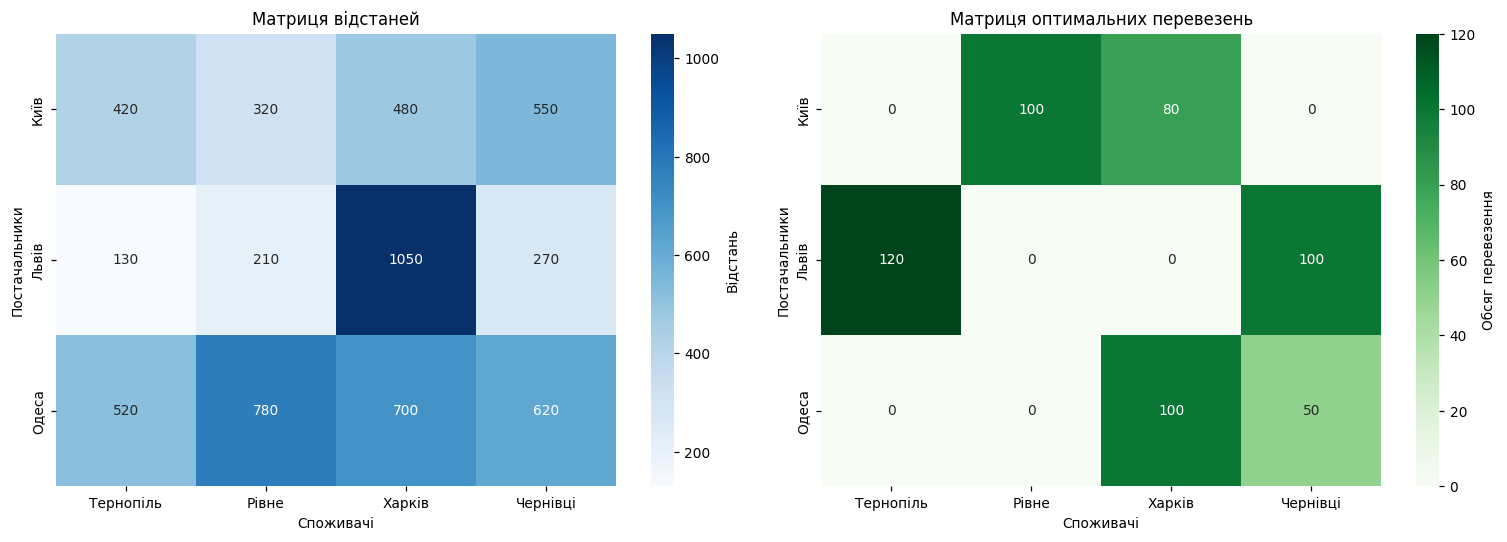

In [24]:
# ВАШ КОД
import seaborn as sns
plan = plan_pulp

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    D,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=споживачі,
    yticklabels=постачальники,
    ax=axes[0],
    cbar_kws={"label": "Відстань"}
)

axes[0].set_title("Матриця відстаней")
axes[0].set_xlabel("Споживачі")
axes[0].set_ylabel("Постачальники")

sns.heatmap(
    plan,
    annot=True,
    fmt=".0f",
    cmap="Greens",
    xticklabels=споживачі,
    yticklabels=постачальники,
    ax=axes[1],
    cbar_kws={"label": "Обсяг перевезення"}
)

axes[1].set_title("Матриця оптимальних перевезень")
axes[1].set_xlabel("Споживачі")
axes[1].set_ylabel("Постачальники")

plt.tight_layout()
plt.show()

**Висновок:** на теплових картах видно, що оптимальні перевезення зосереджені на маршрутах із відносно невеликими відстанями, тоді як більшість маршрутів взагалі не використовується.


---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [25]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'синтаксис',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'ні',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'оскільки я працював у libreoffice, то випитував ші, як мені використати всі ті самі інструменти, як і у excel; також не знав синтаксису для pulp та linprog, бо раніше реалізовували це все тільки руками'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [26]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Штурин Захарій Михайлович
інструменти:                               ChatGPT
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           синтаксис
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   ні
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
оскільки я працював у libreoffice, то випитував ші, як мені використати всі ті самі інструменти, як і у excel; також не знав синтаксису для pulp та linprog, бо раніше реалізовували це все тільки руками


---
# Крок 13. Фінальна самоперевірка

In [27]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
